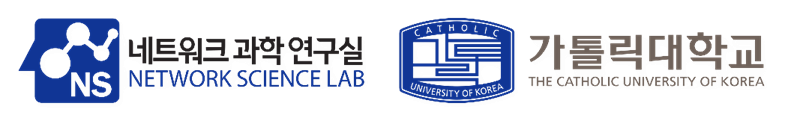

<h1><center><b>💻 Assignment 6:</b> </br>👋 Link Prediction!</center></h1>

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W6/Assignment_6.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> 🌸 **Submission Reminder**
>
> Please make sure to **submit your `.ipynb` (Jupyter Notebook) file** for grading.  
> Other formats such as **PDF, screenshots, or `.py` files** cannot be accepted.  
>
> Thank you and happy coding! 💻✨

# 1. Building a Friend Recommendation System
### 1.1. Load friend network from edge-list file [data/friend_network.txt](data/friend_network.txt)
### 1.2. Complete the following requirements:
- Compute the following coefficient scores to evaluate potential new friendships:
  + Jaccard’s coefficient
  + Adamic-Adar
  + Preferential attachment (PA)
  + SimRank similarity
- Given pair of users who are not yet friends: `[("Ana", "Tino"), ("Mark", "Tim")]`. Calculate and print the metrics for these pairs.

- Recommend the top 3 most likely new friendships out of all unconnected pairs in the network using the **Adamic-Adar index**. Draw the network highlighting nodes by degree and emphasizing these top 3 recommended edges in green dashed lines.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

# Configure plotting
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

# 1.1 Load the friend network
G_friend = nx.read_edgelist('data/friend_network.txt')
print("Friend network loaded:")
print(f"  Nodes: {G_friend.number_of_nodes()}")
print(f"  Edges: {G_friend.number_of_edges()}")
print(f"  Nodes: {sorted(G_friend.nodes())}")

Friend network loaded:
  Nodes: 21
  Edges: 29
  Nodes: ['Ana', 'Bin', 'Brock', 'Elsa', 'Enma', 'Hana', 'Hiro', 'Jack', 'Jan', 'Jin', 'Kevin', 'Lyly', 'Mark', 'Mie', 'Mono', 'Nick', 'Nico', 'Rober', 'Robert', 'Tim', 'Tino']


### Compute metrics for given pairs

In [2]:
target_pairs = [("Ana", "Tino"), ("Mark", "Tim")]

results = []
for u, v in target_pairs:
    # Check not connected
    is_connected = G_friend.has_edge(u, v)
    # Common Neighbors
    cn = sorted(nx.common_neighbors(G_friend, u, v))
    cn_count = len(cn)
    # Jaccard
    jc = list(nx.jaccard_coefficient(G_friend, [(u, v)]))[0][2]
    # Adamic-Adar
    aa = list(nx.adamic_adar_index(G_friend, [(u, v)]))[0][2]
    # Preferential Attachment
    pa = list(nx.preferential_attachment(G_friend, [(u, v)]))[0][2]
    # SimRank
    sr = nx.simrank_similarity(G_friend, source=u, target=v)
    
    results.append({
        "Pair": f"({u}, {v})",
        "Connected?": is_connected,
        "Common Neighbors (CN)": cn_count,
        "CN nodes": str(cn),
        "Jaccard (JC)": round(jc, 4),
        "Adamic-Adar (AA)": round(aa, 4),
        "Preferential Attachment (PA)": pa,
        "SimRank": round(sr, 4)
    })

df_friend = pd.DataFrame(results)
print("=== Link Prediction Metrics for Specified Pairs ===")
display(df_friend)

=== Link Prediction Metrics for Specified Pairs ===


,Pair,Connected?,Common Neighbors (CN),CN nodes,Jaccard (JC),Adamic-Adar (AA),Preferential Attachment (PA),SimRank
0,"(Ana, Tino)",False,1,['Nico'],0.1429,0.5581,15,0.3025
1,"(Mark, Tim)",False,1,['Hana'],0.2500,1.4427,6,0.3951


### Recommend top 3 new friendships using Adamic-Adar

In [3]:
# Get all non-edge Adamic-Adar scores
aa_all = list(nx.adamic_adar_index(G_friend))
# Sort by score descending, take top 3
aa_all_sorted = sorted(aa_all, key=lambda x: x[2], reverse=True)
top3_recs = aa_all_sorted[:3]

print("=== Top 3 Recommended New Friendships (by Adamic-Adar) ===")
for i, (u, v, score) in enumerate(top3_recs, 1):
    print(f"{i}. ({u}, {v}) - AA score: {score:.4f}")

# Store recommended edges for visualization
rec_edges = [(u, v) for u, v, _ in top3_recs]

=== Top 3 Recommended New Friendships (by Adamic-Adar) ===
1. (Mie, Mono) - AA score: 2.0640
2. (Tino, Brock) - AA score: 2.0008
3. (Ana, Brock) - AA score: 2.0008


### Visualization: Network with nodes sized by degree + top-3 recommended edges (green dashed)

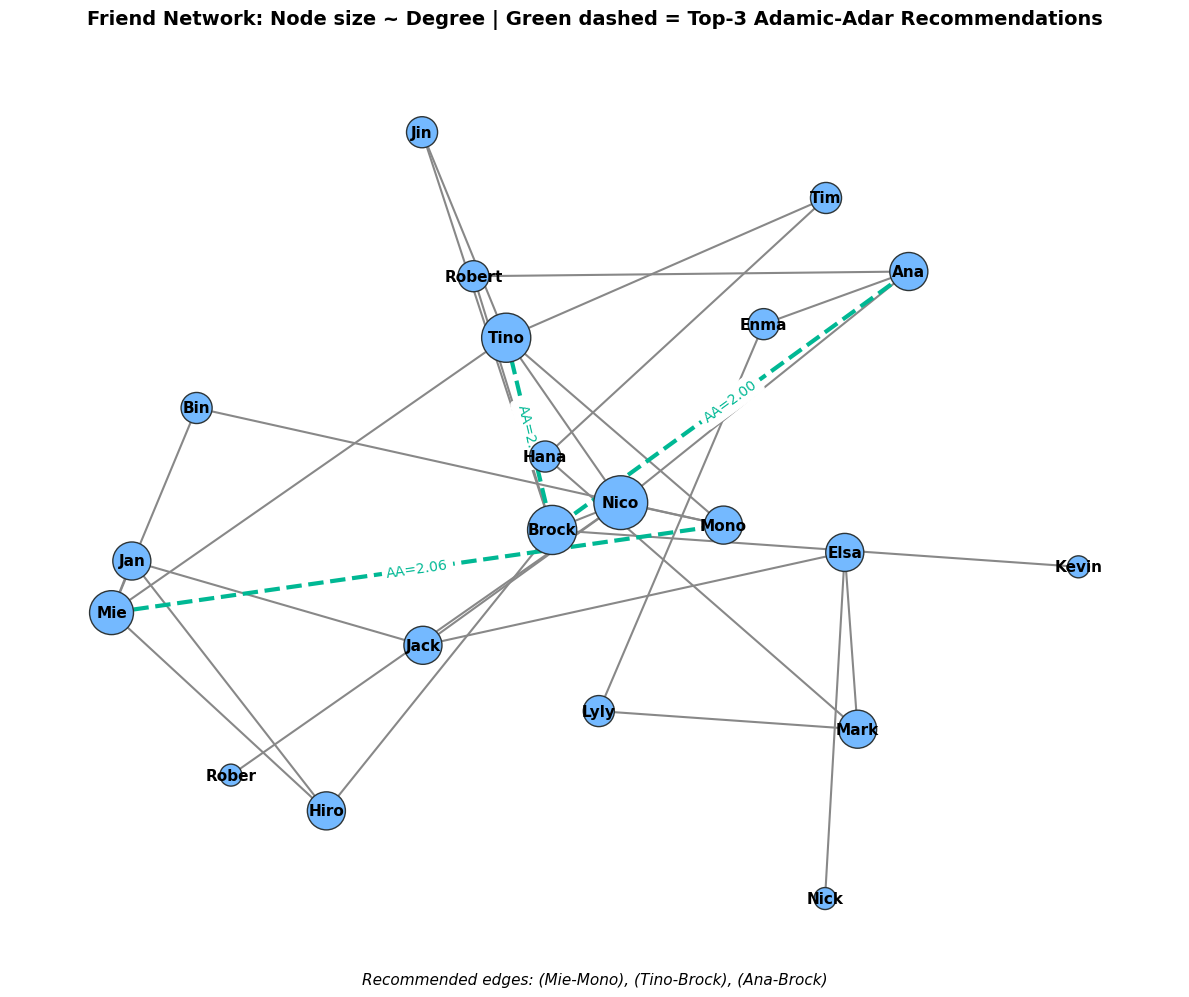

In [12]:
# Draw the friend network
pos = nx.spring_layout(G_friend, seed=42, k=1.2)

# Node sizes proportional to degree
degrees = dict(G_friend.degree())
node_sizes = [degrees[n] * 250 for n in G_friend.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw(
    G_friend, pos,
    ax=ax,
    with_labels=True,
    node_color='#74b9ff',
    node_size=node_sizes,
    edge_color='#888888',
    width=1.5,
    font_size=11,
    font_weight='bold',
    edgecolors='#2d3436'
)

# Highlight recommended edges in green dashed
nx.draw_networkx_edges(
    G_friend, pos,
    edgelist=rec_edges,
    style='dashed',
    edge_color='#00b894',
    width=3,
    ax=ax
)

# Add edge labels for the recommended scores
edge_labels = {(u, v): f"AA={s:.2f}" for u, v, s in top3_recs}
nx.draw_networkx_edge_labels(
    G_friend, pos,
    edge_labels=edge_labels,
    font_color='#00b894',
    font_size=10,
    ax=ax
)

# Title and legend info
ax.set_title("Friend Network: Node size ~ Degree | Green dashed = Top-3 Adamic-Adar Recommendations", 
             fontsize=14, fontweight='bold', pad=20)

# Add a small legend text
plt.figtext(0.5, 0.01, "Recommended edges: " + ", ".join([f"({u}-{v})" for u,v,_ in top3_recs]),
            ha="center", fontsize=11, style='italic')

plt.tight_layout()
plt.show()

# 2. Predicting Missing Protein Interactions
### 2.1 Exploring Known Target Pairs

Biological networks are often incomplete. Your task is to predict which proteins are most likely to interact using link prediction algorithms on the `SC-TS` dataset.

+ Load the protein interaction network from [data/SC-TS.txt](data/SC-TS.txt).
+ Read the specific pairs of proteins we want to test from [data/node_pairs.txt](data/node_pairs.txt).
+ Calculate common neighbors (CN), Jaccard (JC), Adamic-Adar (AA), Preferential attachment (PA) and SimRank similarity for these specific pairs.
+ **Improved Visualization**: Instead of plotting the entire massive network ("hairball"), extract the **Ego-Network** (the neighborhood graph) containing these specific nodes and their immediate neighbors. Plot this subgraph to visually understand *why* they might interact (e.g., showing their shared neighbors).

*(Note: In the node pairs file, each row contains 2 columns corresponding to 2 proteins.)*

In [5]:
G_protein = nx.read_edgelist('data/SC-TS.txt', data=False)
print("SC-TS Protein network loaded:")
print(f"  Nodes: {G_protein.number_of_nodes()}")
print(f"  Edges: {G_protein.number_of_edges()}")
print(f"  Connected components: {nx.number_connected_components(G_protein)}")
print(f"  Largest CC size: {max(len(c) for c in nx.connected_components(G_protein))}")

SC-TS Protein network loaded:
  Nodes: 636
  Edges: 3959
  Connected components: 81
  Largest CC size: 67


In [6]:
with open('data/node_pairs.txt', 'r') as f:
    protein_pairs = [tuple(line.strip().split()) for line in f if line.strip()]

print("Protein pairs from node_pairs.txt:")
for i, p in enumerate(protein_pairs, 1):
    print(f"  {i}. {p}  (currently connected: {G_protein.has_edge(p[0], p[1])})")

Protein pairs from node_pairs.txt:
  1. ('F17E9.12', 'F45E1.6')  (currently connected: True)
  2. ('C50F4.5', 'T23D8.5')  (currently connected: True)
  3. ('B0035.8', 'B0035.10')  (currently connected: True)


#### Compute CN, JC, AA, PA, SimRank for the specific pairs

In [13]:
protein_results = []
all_target_nodes = set()

for u, v in protein_pairs:
    all_target_nodes.add(u)
    all_target_nodes.add(v)
    
    cn_nodes = sorted(nx.common_neighbors(G_protein, u, v))
    cn_count = len(cn_nodes)
    
    jc = list(nx.jaccard_coefficient(G_protein, [(u, v)]))[0][2]
    aa = list(nx.adamic_adar_index(G_protein, [(u, v)]))[0][2]
    pa = list(nx.preferential_attachment(G_protein, [(u, v)]))[0][2]
    
    # SimRank
    try:
        sr = nx.simrank_similarity(G_protein, source=u, target=v)
    except Exception as e:
        sr = None
        print(f"SimRank failed for {u}-{v}: {e}")
    
    protein_results.append({
        "Pair": f"({u}, {v})",
        "CN": cn_count,
        "Jaccard (JC)": round(jc, 4),
        "Adamic-Adar (AA)": round(aa, 4),
        "Preferential Attachment (PA)": pa,
        "SimRank": round(sr, 4) if sr is not None else "N/A"
    })

df_protein = pd.DataFrame(protein_results)
print("=== Link Prediction Metrics for Known Target Protein Pairs ===")
display(df_protein)

=== Link Prediction Metrics for Known Target Protein Pairs ===


,Pair,CN,Jaccard (JC),Adamic-Adar (AA),Preferential Attachment (PA),SimRank
0,"(F17E9.12, F45E1.6)",65,0.9701,15.5144,4356,0.118
1,"(C50F4.5, T23D8.5)",65,0.9701,15.5144,4356,0.118
2,"(B0035.8, B0035.10)",65,0.9701,15.5144,4356,0.118


#### Ego-Network Visualization for the target pairs + immediate neighbors

We extract the subgraph induced by the 6 target proteins and all their direct neighbors (union of neighborhoods). This reveals the dense shared-neighbor structure explaining their high link-prediction scores.

Ego-network subgraph:
  Total nodes: 67
  Total edges: 2211
  Target proteins in subgraph: ['B0035.10', 'B0035.8', 'C50F4.5', 'F17E9.12', 'F45E1.6', 'T23D8.5']


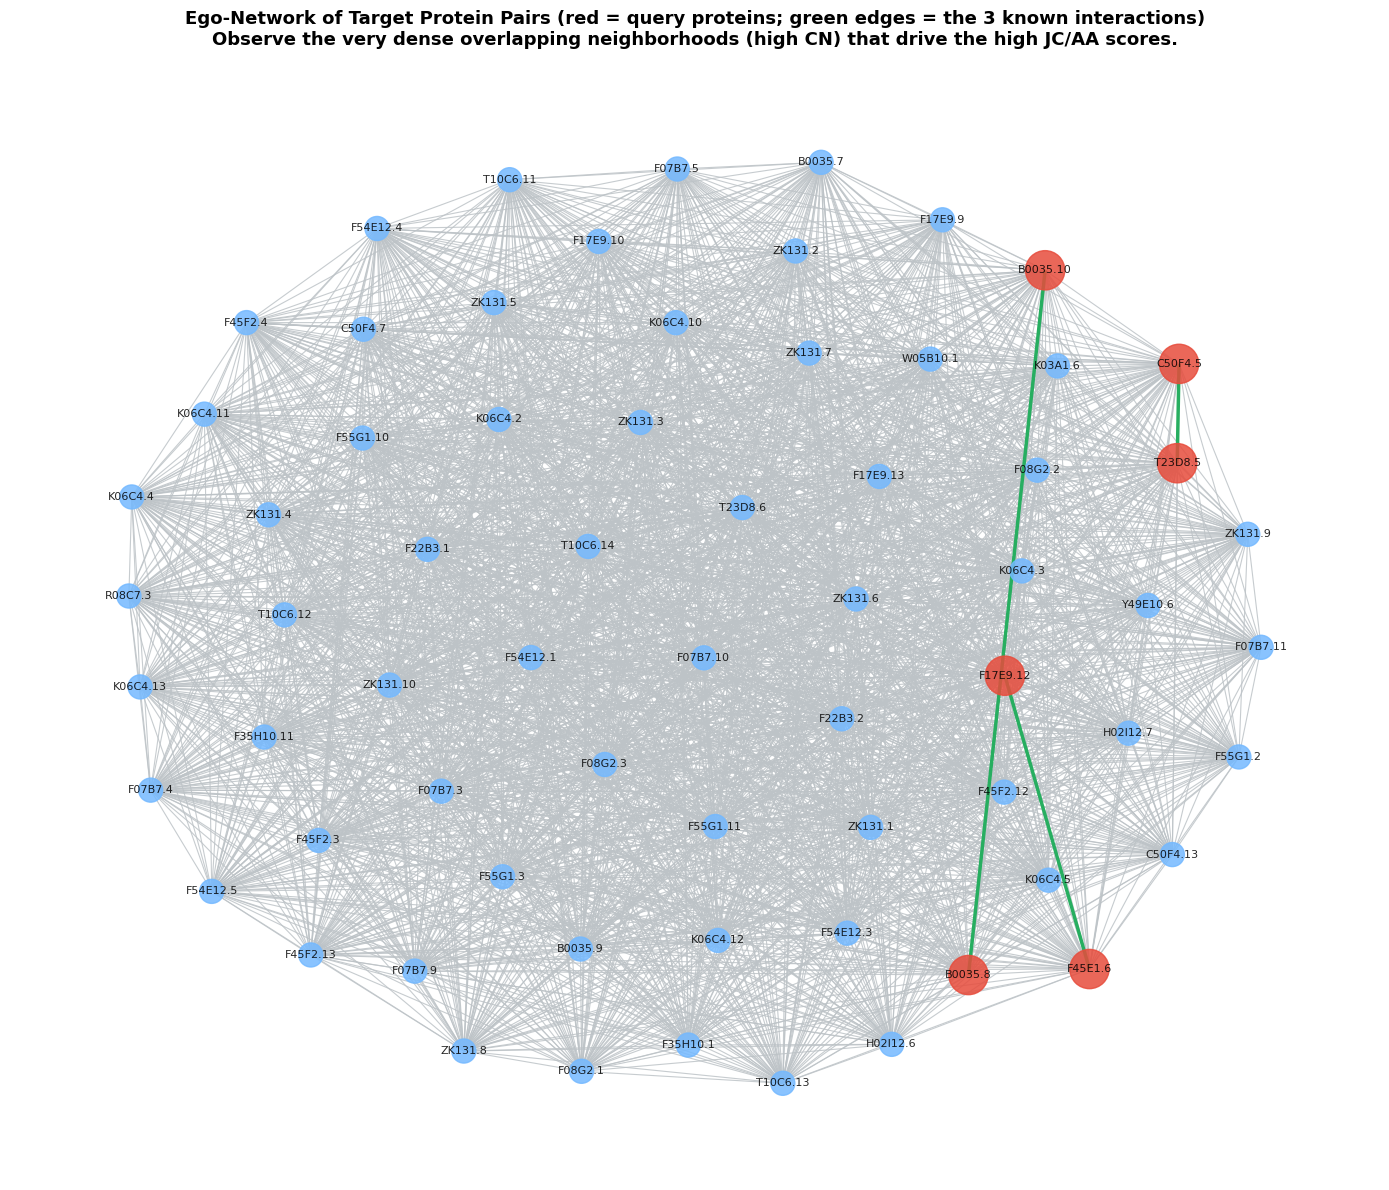

In [9]:
# Build ego-network: targets + all their neighbors
neighbor_nodes = set()
for n in all_target_nodes:
    neighbor_nodes.update(G_protein.neighbors(n))

ego_nodes = all_target_nodes | neighbor_nodes
G_ego = G_protein.subgraph(ego_nodes).copy()

print(f"Ego-network subgraph:")
print(f"  Total nodes: {G_ego.number_of_nodes()}")
print(f"  Total edges: {G_ego.number_of_edges()}")
print(f"  Target proteins in subgraph: {sorted(all_target_nodes)}")

# Draw the ego net
pos_ego = nx.spring_layout(G_ego, seed=123, k=0.8)

# Color: target nodes = red, others = light blue
node_colors = ['#e74c3c' if n in all_target_nodes else '#74b9ff' for n in G_ego.nodes()]
node_sizes_ego = [800 if n in all_target_nodes else 300 for n in G_ego.nodes()]

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw(
    G_ego, pos_ego,
    ax=ax,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes_ego,
    edge_color='#bdc3c7',
    width=0.8,
    font_size=8,
    font_weight='normal',
    alpha=0.85
)

nx.draw_networkx_edges(
    G_ego, pos_ego,
    edgelist=protein_pairs,
    style='solid',
    edge_color='#27ae60',
    width=2.5,
    ax=ax
)

ax.set_title(
    "Ego-Network of Target Protein Pairs (red = query proteins; green edges = the 3 known interactions)\n"
    "Observe the very dense overlapping neighborhoods (high CN) that drive the high JC/AA scores.",
    fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.show()

## 2.2 Finding the Strongest Predictions 

Let's identify the most promising unconnected proteins in the entire network that should be tested experimentally!

+ What are the top 5 pairs of predicted protein interactions with the highest **Jaccard (JC)** similarity? 
+ What are the top 5 pairs of predicted protein interactions with the highest **Adamic-Adar (AA)** index? 
+ What are the top 5 pairs of predicted protein interactions with the highest **Preferential Attachment (PA)** score?

In [11]:
# Jaccard top 5
jc_all = list(nx.jaccard_coefficient(G_protein))
jc_top5 = sorted(jc_all, key=lambda x: x[2], reverse=True)[:5]

print("\n=== Top 5 Predicted Interactions by Jaccard Coefficient (JC) ===")
df_jc = pd.DataFrame([{"Rank": i+1, "Pair": f"({u}, {v})", "Jaccard": round(p, 4)} 
                      for i, (u,v,p) in enumerate(jc_top5)])
display(df_jc)

# Adamic-Adar top 5
aa_all = list(nx.adamic_adar_index(G_protein))
aa_top5 = sorted(aa_all, key=lambda x: x[2], reverse=True)[:5]

print("\n=== Top 5 Predicted Interactions by Adamic-Adar Index (AA) ===")
df_aa = pd.DataFrame([{"Rank": i+1, "Pair": f"({u}, {v})", "Adamic-Adar": round(p, 4)} 
                      for i, (u,v,p) in enumerate(aa_top5)])
display(df_aa)

# Preferential Attachment top 5
pa_all = list(nx.preferential_attachment(G_protein))
pa_top5 = sorted(pa_all, key=lambda x: x[2], reverse=True)[:5]

print("\n=== Top 5 Predicted Interactions by Preferential Attachment (PA) ===")
df_pa = pd.DataFrame([{"Rank": i+1, "Pair": f"({u}, {v})", "Preferential Attachment": p} 
                      for i, (u,v,p) in enumerate(pa_top5)])
display(df_pa)

print("\nNote: JC=1.0 pairs have *identical* neighbor sets (perfect structural equivalence).")
print("High PA pairs involve hubs (high-degree nodes) that are likely to gain more links.")


=== Top 5 Predicted Interactions by Jaccard Coefficient (JC) ===


,Rank,Pair,Jaccard
0,1,"(Y87G2A.9, M7.1)",1.0
1,2,"(Y87G2A.9, F29B9.6)",1.0
2,3,"(ZK6.7, F01G10.7)",1.0
3,4,"(ZK6.7, Y57E12B.3)",1.0
4,5,"(ZK6.7, F46B6.8)",1.0



=== Top 5 Predicted Interactions by Adamic-Adar Index (AA) ===


,Rank,Pair,Adamic-Adar
0,1,"(T05F1.10, T02E1.5)",18.8175
1,2,"(T05F1.10, T11F9.11)",18.8175
2,3,"(F11A5.12, C06B3.5)",15.8813
3,4,"(F11A5.12, F25G6.5)",15.8813
4,5,"(F11A5.12, C56G2.6)",15.8813



=== Top 5 Predicted Interactions by Preferential Attachment (PA) ===


,Rank,Pair,Preferential Attachment
0,1,"(F07B7.11, T02E1.5)",3102
1,2,"(F07B7.11, T11F9.11)",3102
2,3,"(K06C4.11, T02E1.5)",3102
3,4,"(K06C4.11, T11F9.11)",3102
4,5,"(K06C4.4, T02E1.5)",3102



Note: JC=1.0 pairs have *identical* neighbor sets (perfect structural equivalence).
High PA pairs involve hubs (high-degree nodes) that are likely to gain more links.
